<a href="https://colab.research.google.com/github/jcjcjjc-kekeodt/CPE-311/blob/main/Hands_on_Activity_9_1_Data_Visualization_using_Pandas_and_Matplotlib_DEBOLGADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Hands-on Activity 9.1**


#**Instructions:** <br>
* Create a Python notebook to answer all shown procedures, exercises and analysis in this section.

#**Resources:**
* Download the following datasets: earthquakes-1.csv Download earthquakes-1.csv, fb_stock_prices_2018.csv

#**Procedures:**


**9.1 Introduction to Matplotlib**


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

*Plotting Lines*

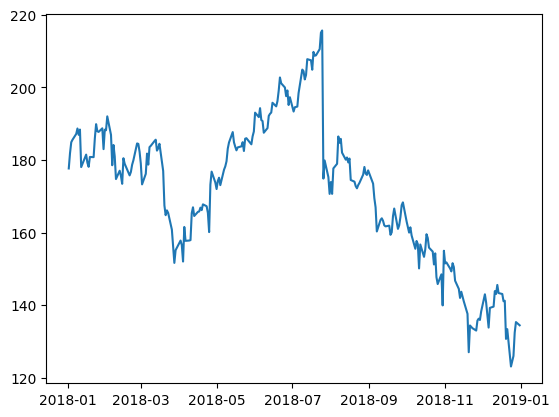

In [3]:
fb = pd.read_csv('fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)
plt.plot(fb.index, fb.open)
plt.show()

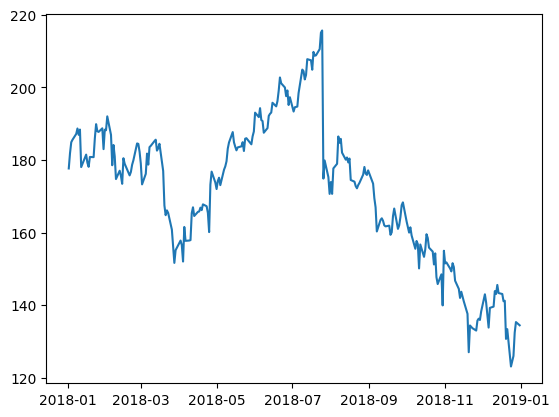

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
fb = pd.read_csv('fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)
plt.plot(fb.index, fb.open)

*Scatter Plots*

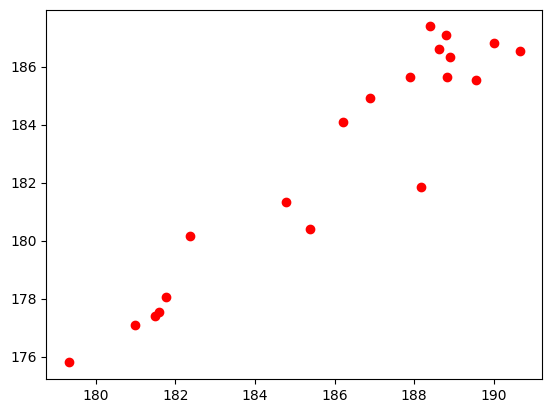

In [9]:
plt.plot('high', 'low', 'ro', data=fb.head(20))

*Histograms*

(array([6.400e+01, 4.450e+02, 1.137e+03, 1.853e+03, 2.114e+03, 8.070e+02,
        2.800e+02, 9.200e+01, 9.000e+00, 2.000e+00]),
 array([-1.26 , -0.624,  0.012,  0.648,  1.284,  1.92 ,  2.556,  3.192,
         3.828,  4.464,  5.1  ]),
 <BarContainer object of 10 artists>)

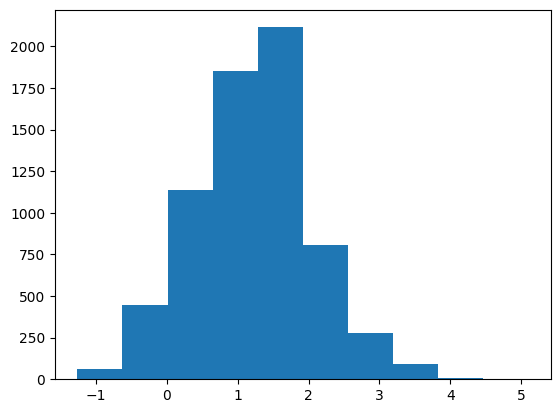

In [13]:
quakes = pd.read_csv('earthquakes-1.csv')
plt.hist(quakes.query('magType == "ml"').mag)

*Bin size matters*

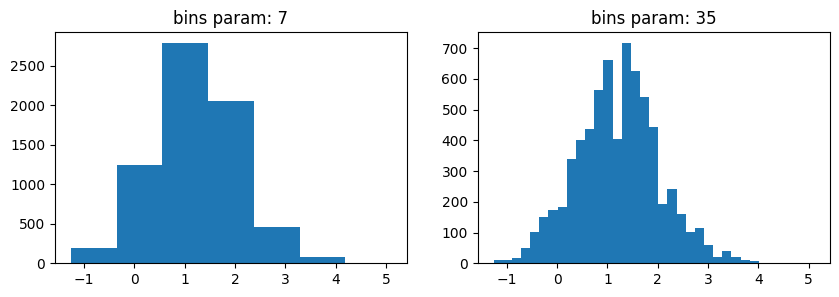

In [15]:
x = quakes.query('magType == "ml"').mag
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, bins in zip(axes, [7, 35]):
  ax.hist(x, bins=bins)
  ax.set_title(f'bins param: {bins}')

**Plot Components** <BR>
*Figure*

In [16]:
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

*Axes* <BR>
Individual plots contained within the Figure .

*Creating subplots*

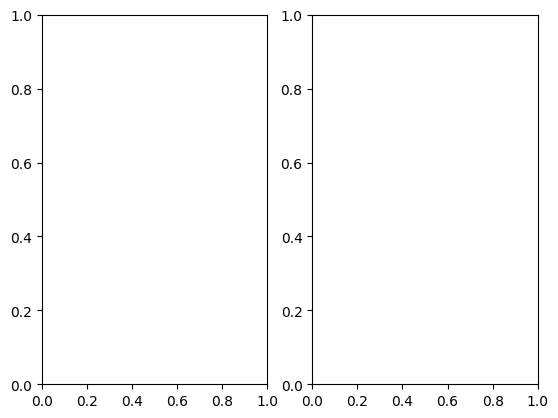

In [17]:
fig, axes = plt.subplots(1, 2)

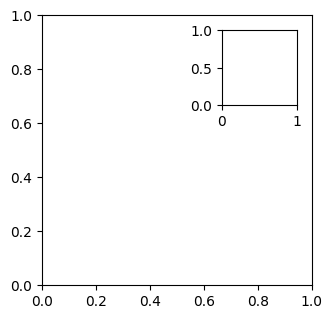

In [18]:
fig = plt.figure(figsize=(3, 3))
outside = fig.add_axes([0.1, 0.1, 0.9, 0.9])
inside = fig.add_axes([0.7, 0.7, 0.25, 0.25])

*Creating Plot Layouts with gridspec*

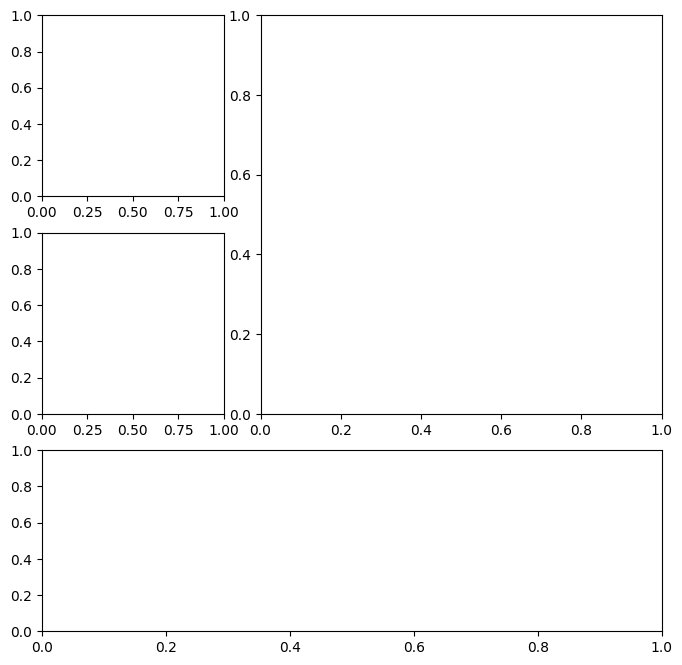

In [19]:
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(3, 3)
top_left = fig.add_subplot(gs[0, 0])
mid_left = fig.add_subplot(gs[1, 0])
top_right = fig.add_subplot(gs[:2, 1:])
bottom = fig.add_subplot(gs[2,:])

*Saving plots*

In [20]:
fig.savefig('empty.png')

*Cleaning up*

In [21]:
plt.close('all')

**Additional plotting options**

*Specifying figure size*

In [22]:
fig = plt.figure(figsize=(10, 4))

<Figure size 1000x400 with 0 Axes>

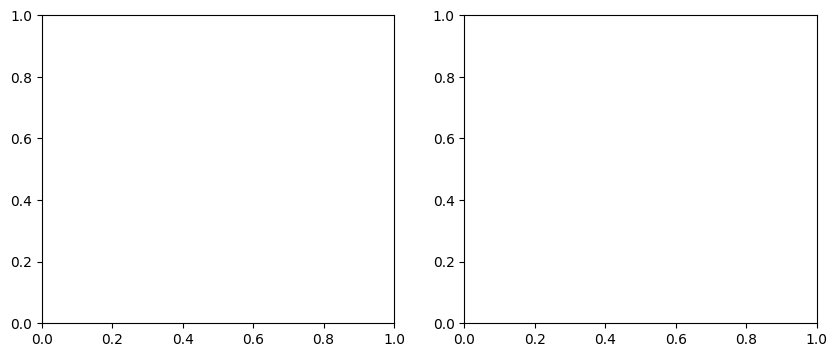

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

*rcParams*

In [24]:
import random
import matplotlib as mpl

rcparams_list = list(mpl.rcParams.keys())
random.seed(20) # make this repeatable
random.shuffle(rcparams_list)
sorted(rcparams_list[:20])

['axes.edgecolor',
 'axes.titleweight',
 'boxplot.whiskerprops.linestyle',
 'date.autoformatter.day',
 'figure.constrained_layout.hspace',
 'figure.titlesize',
 'image.interpolation_stage',
 'keymap.copy',
 'legend.framealpha',
 'legend.handleheight',
 'lines.dash_joinstyle',
 'lines.markerfacecolor',
 'mathtext.default',
 'mathtext.fallback',
 'pdf.compression',
 'svg.fonttype',
 'text.usetex',
 'yaxis.labellocation',
 'ytick.major.size',
 'ytick.minor.visible']

In [25]:
mpl.rcParams['figure.figsize']

[6.4, 4.8]

In [26]:
mpl.rcParams['figure.figsize'] = (300, 10)
mpl.rcParams['figure.figsize']

[300.0, 10.0]

In [27]:
mpl.rcdefaults()
mpl.rcParams['figure.figsize']

[6.4, 4.8]

In [28]:
plt.rc('figure', figsize=(20, 20)) # change figsize default to (20, 20)
plt.rcdefaults() # reset the default

**9.2 Plotting with Pandas**


*Setup*

In [29]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
fb = pd.read_csv(
'fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)
quakes = pd.read_csv('earthquakes-1.csv')


*Evolution over time*

<Axes: title={'center': 'Evolution of Facebook Open Price'}, xlabel='date'>

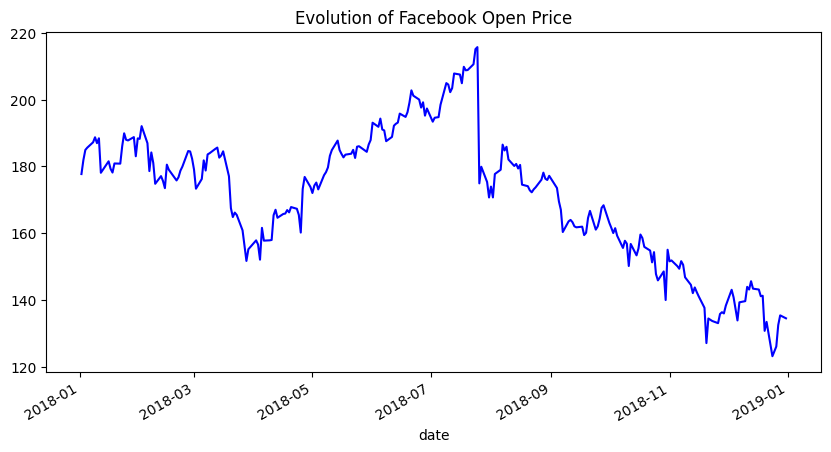

In [30]:
fb.plot(
  kind='line',
  y='open',
  figsize=(10, 5),
  style='b-',
  legend=False,
  title='Evolution of Facebook Open Price'
)

<Axes: title={'center': 'Evolution of Facebook Open Price'}, xlabel='date'>

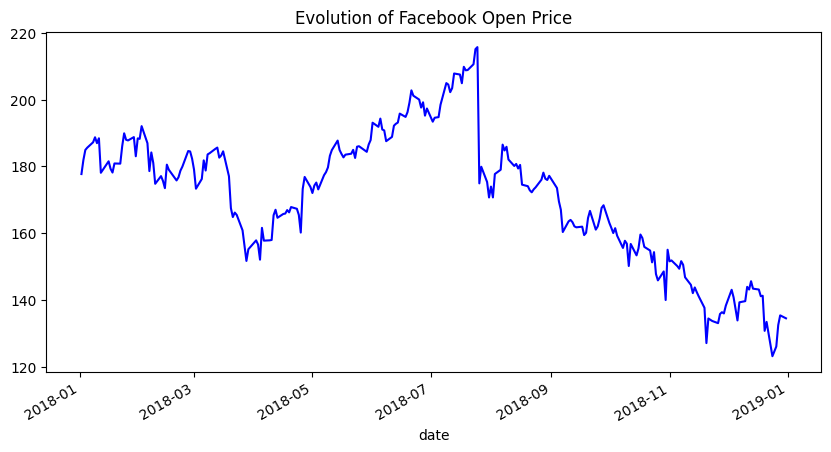

In [31]:
fb.plot(
  kind='line',
  y='open',
  figsize=(10, 5),
  color='blue',
  linestyle='solid',
  legend=False,
  title='Evolution of Facebook Open Price'
)

<Axes: title={'center': 'Facebook OHLC Prices during 1st Week of Trading 2018'}, xlabel='date'>

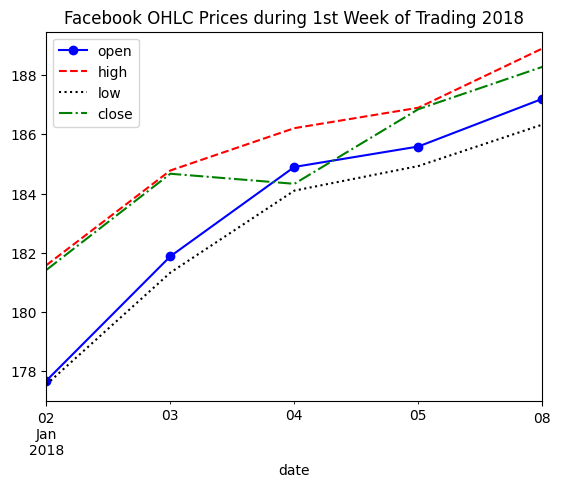

In [32]:
fb.iloc[:5,].plot(
  y=['open', 'high', 'low', 'close'],
  style=['b-o', 'r--', 'k:', 'g-.'],
  title='Facebook OHLC Prices during 1st Week of Trading 2018'
)

*Creating subplots*

array([[<Axes: xlabel='date'>, <Axes: xlabel='date'>],
       [<Axes: xlabel='date'>, <Axes: xlabel='date'>],
       [<Axes: xlabel='date'>, <Axes: xlabel='date'>]], dtype=object)

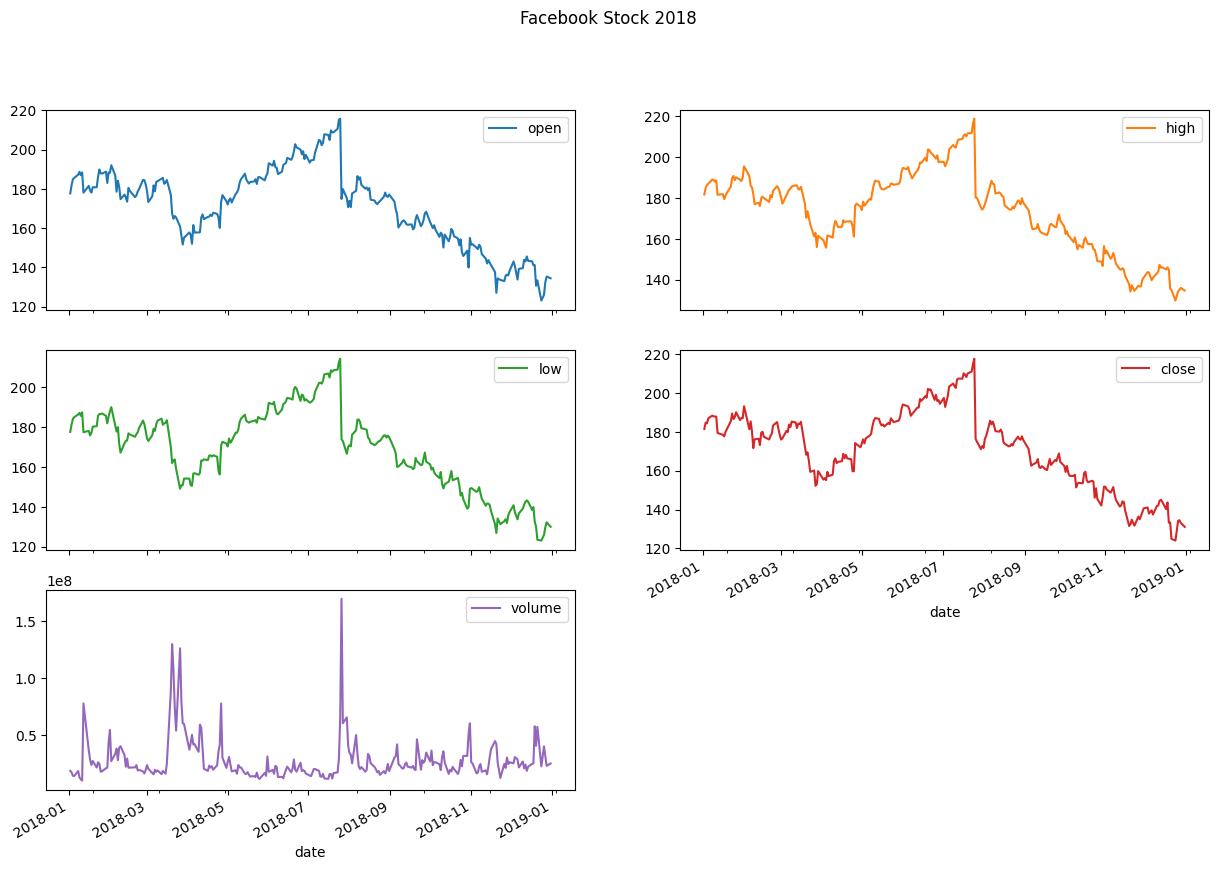

In [33]:
fb.plot(
  kind='line',
  subplots=True,
  layout=(3,2),
  figsize=(15,10),
  title='Facebook Stock 2018'
)

**Visualizing relationships between variables**

*Scatter plots*

<Axes: title={'center': 'Facebook Daily High - Low vs. Volume Traded'}, xlabel='volume', ylabel='max_abs_change'>

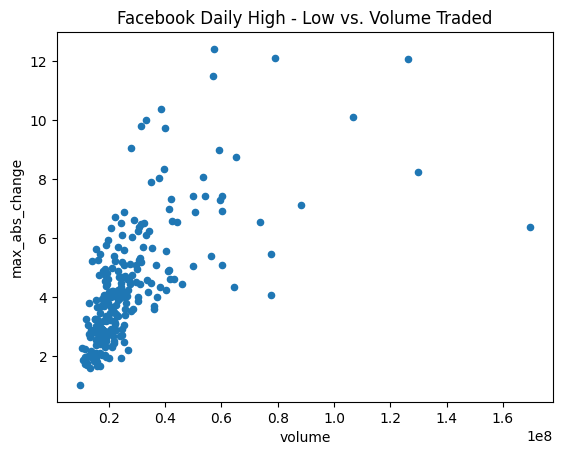

In [34]:
fb.assign(
  max_abs_change=fb.high - fb.low
).plot(
  kind='scatter', x='volume', y='max_abs_change',
  title='Facebook Daily High - Low vs. Volume Traded'
)

<Axes: title={'center': 'Facebook Daily High - Low vs. log(Volume Traded)'}, xlabel='volume', ylabel='max_abs_change'>

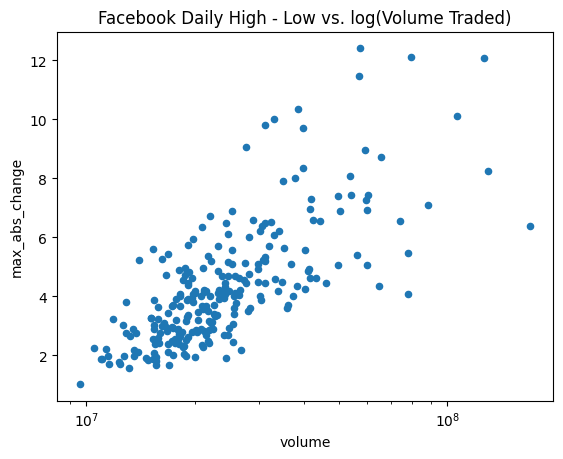

In [36]:
fb.assign(
  max_abs_change=fb.high - fb.low
).plot(
  kind='scatter', x='volume', y='max_abs_change',
  title='Facebook Daily High - Low vs. log(Volume Traded)',
  logx=True
)

*Adding Transparency to Plots with alpha*

<Axes: title={'center': 'Facebook Daily High - Low vs. log(Volume Traded)'}, xlabel='volume', ylabel='max_abs_change'>

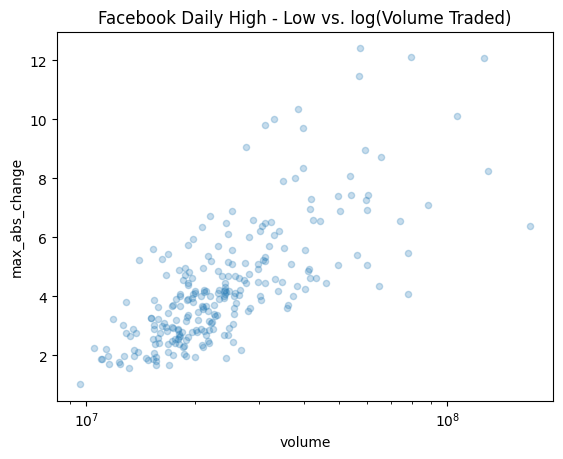

In [37]:
fb.assign(
  max_abs_change=fb.high - fb.low
).plot(
  kind='scatter', x='volume', y='max_abs_change',
  title='Facebook Daily High - Low vs. log(Volume Traded)',
  logx=True, alpha=0.25
)

*Hexbins*

<Axes: title={'center': 'Facebook Daily High - Low vs. log(Volume Traded)'}, xlabel='log_volume', ylabel='max_abs_change'>

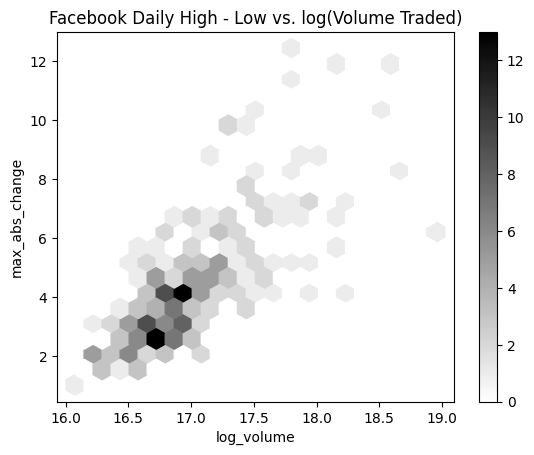

In [38]:
fb.assign(
  log_volume=np.log(fb.volume),
  max_abs_change=fb.high - fb.low
).plot(
  kind='hexbin',
  x='log_volume',
  y='max_abs_change',
  title='Facebook Daily High - Low vs. log(Volume Traded)',
  colormap='gray_r',
  gridsize=20,
  sharex=False # we have to pass this to see the x-axis due to a bug in this version of pandas
)

*Visualizing Correlations with Heatmaps*

[Text(0, 0, 'open'),
 Text(0, 1, 'high'),
 Text(0, 2, 'low'),
 Text(0, 3, 'close'),
 Text(0, 4, 'volume'),
 Text(0, 5, 'log_volume'),
 Text(0, 6, 'max_abs_change')]

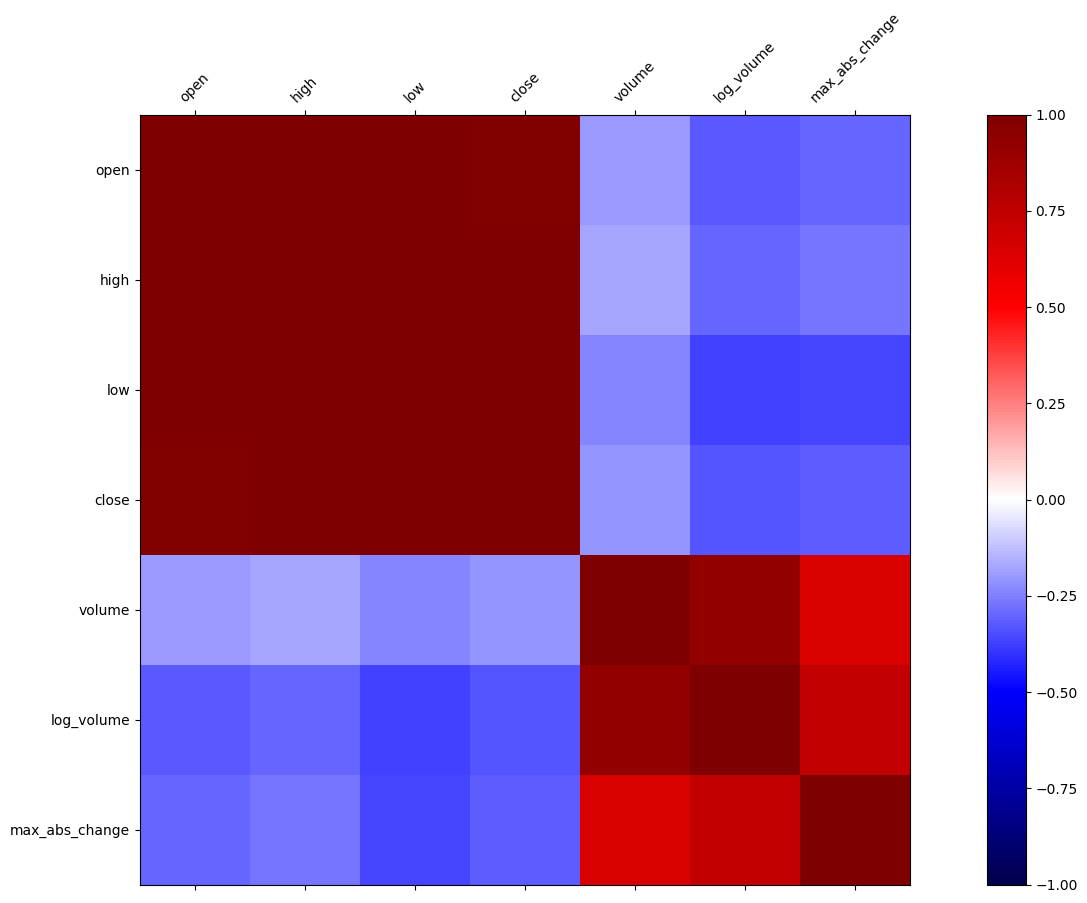

In [43]:
fig, ax = plt.subplots(figsize=(20, 10))

fb_corr = fb.assign(
    log_volume=np.log(fb.volume),
    max_abs_change=fb.high - fb.low
).corr()

im = ax.matshow(fb_corr, cmap='seismic')

cbar = fig.colorbar(im)
im.set_clim(-1, 1)

labels = [col.lower() for col in fb_corr.columns]
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45)
ax.set_yticklabels(labels)


In [44]:
fb_corr.loc['max_abs_change', ['volume', 'log_volume']]

,max_abs_change
volume,0.642027
log_volume,0.731542


**Visualizing distributions**

*Histograms*

Text(0.5, 0, 'Volume traded')

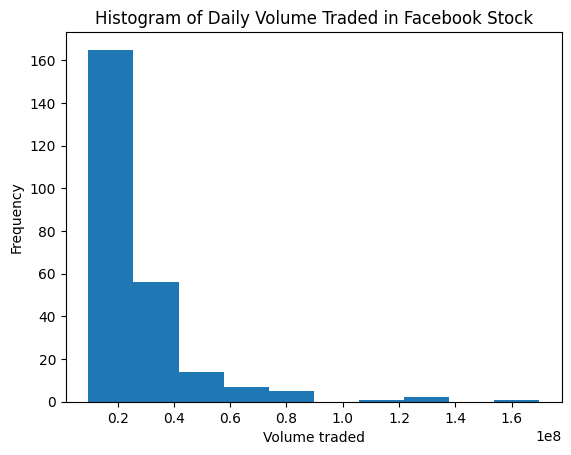

In [45]:
fb.volume.plot(
  kind='hist',
  title='Histogram of Daily Volume Traded in Facebook Stock'
)
plt.xlabel('Volume traded') # label the x-axis (discussed in chapter 6)

Text(0.5, 0, 'magnitude')

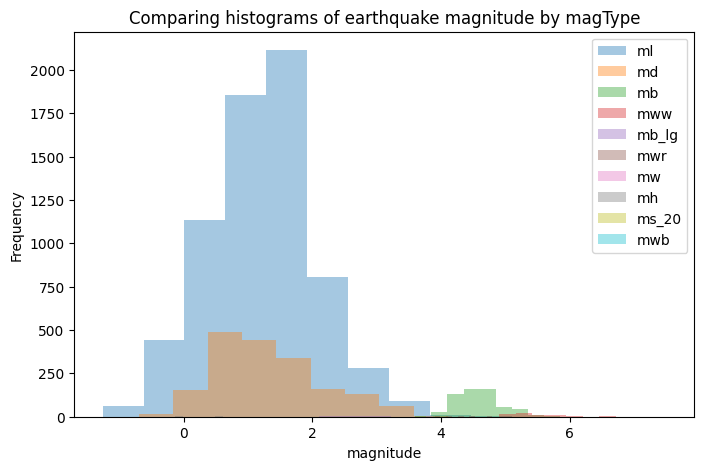

In [46]:
fig, axes = plt.subplots(figsize=(8, 5))
for magtype in quakes.magType.unique():
  data = quakes.query(f'magType == "{magtype}"').mag
  if not data.empty:
    data.plot(
      kind='hist', ax=axes, alpha=0.4,
      label=magtype, legend=True,
title='Comparing histograms of earthquake magnitude by magType'
)
plt.xlabel('magnitude') # label the x-axis (discussed in chapter 6)

*Kernel Density Estimation (KDE)*

Text(0.5, 0, 'Price ($)')

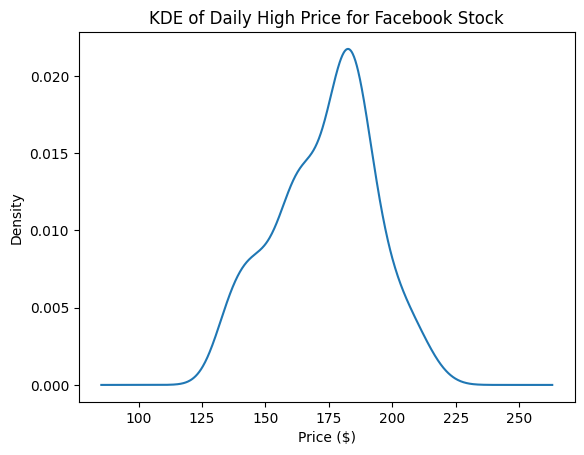

In [48]:
fb.high.plot(
  kind='kde',
  title='KDE of Daily High Price for Facebook Stock'
)
plt.xlabel('Price ($)') # label the x-axis (discussed in chapter 6)

*Adding to the result of plot()*

Text(0.5, 0, 'Price ($)')

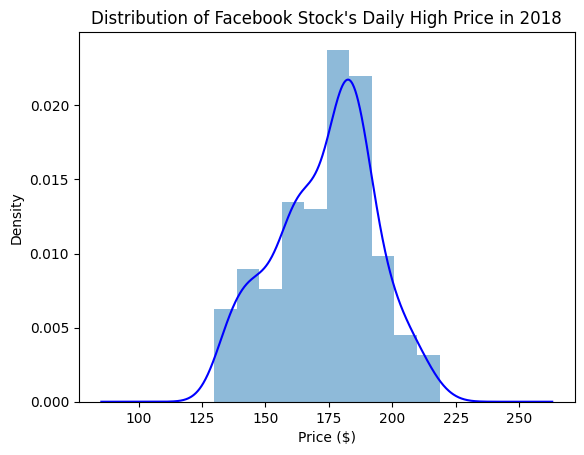

In [49]:
ax = fb.high.plot(kind='hist', density=True, alpha=0.5)
fb.high.plot(
  ax=ax, kind='kde', color='blue',
  title='Distribution of Facebook Stock\'s Daily High Price in 2018'
)
plt.xlabel('Price ($)') # label the x-axis (discussed in chapter 6)

*Plotting the ECDF*

Text(0.5, 1.0, 'ECDF of earthquake magnitude with magType ml')

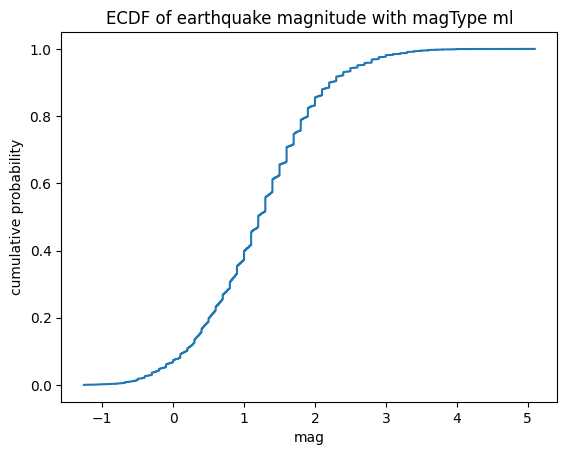

In [50]:
from statsmodels.distributions.empirical_distribution import ECDF

ecdf = ECDF(quakes.query('magType == "ml"').mag)
plt.plot(ecdf.x, ecdf.y)

# axis labels (we will cover this in chapter 6)
plt.xlabel('mag') # add x-axis label
plt.ylabel('cumulative probability') # add y-axis label

# add title (we will cover this in chapter 6)
plt.title('ECDF of earthquake magnitude with magType ml')

Text(0.5, 1.0, 'P(mag <= 3) = 98%')

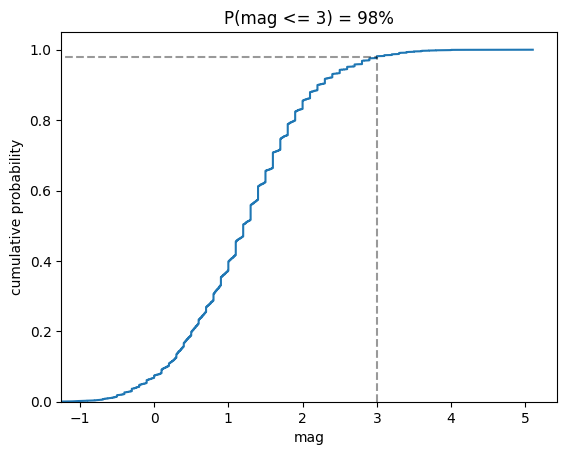

In [51]:
from statsmodels.distributions.empirical_distribution import ECDF

ecdf = ECDF(quakes.query('magType == "ml"').mag)
plt.plot(ecdf.x, ecdf.y)

# formatting below will all be covered in chapter 6
# axis labels
plt.xlabel('mag') # add x-axis label
plt.ylabel('cumulative probability') # add y-axis label

# add reference lines for interpreting the ECDF for mag <= 3
plt.plot(
[3, 3], [0, .98], 'k--',
[-1.5, 3], [0.98, 0.98], 'k--', alpha=0.4
)

# set axis ranges
plt.ylim(0, None)
plt.xlim(-1.25, None)

# add a title
plt.title('P(mag <= 3) = 98%')

*Box plots*

Text(0, 0.5, 'price ($)')

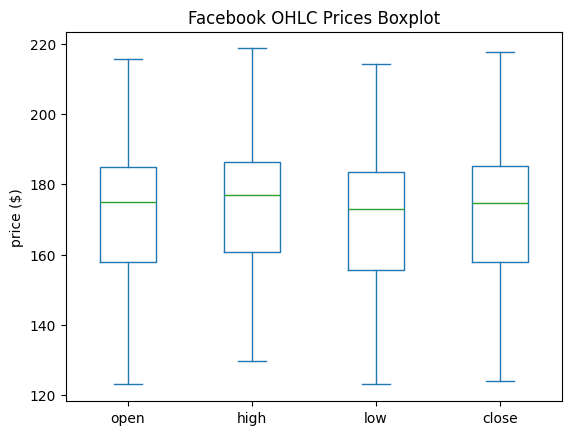

In [52]:
fb.iloc[:,:4].plot(kind='box', title='Facebook OHLC Prices Boxplot')
plt.ylabel('price ($)') # label the x-axis (discussed in chapter 6)

/tmp/ipykernel_762/2907583901.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ).groupby('volume_bin').boxplot(


Text(0.5, 1.1, 'Facebook OHLC Boxplots by Volume Traded')

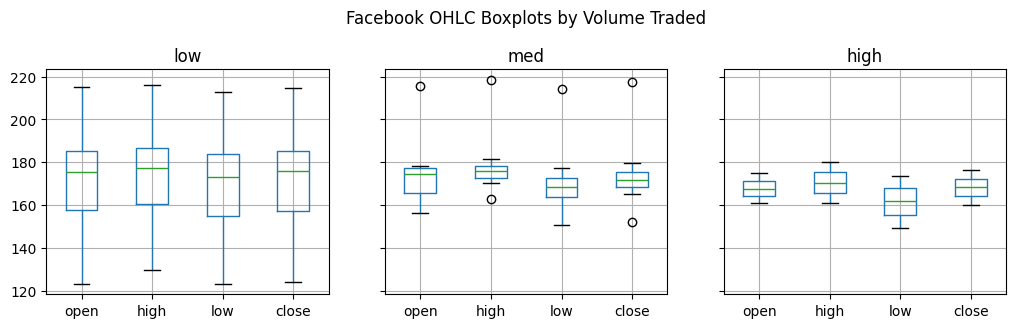

In [53]:
fb.assign(
  volume_bin=pd.cut(fb.volume, 3, labels=['low', 'med', 'high'])
).groupby('volume_bin').boxplot(
  column=['open', 'high', 'low', 'close'],
  layout=(1, 3), figsize=(12, 3)
)
plt.suptitle('Facebook OHLC Boxplots by Volume Traded', y=1.1)

Text(0, 0.5, 'magnitude')

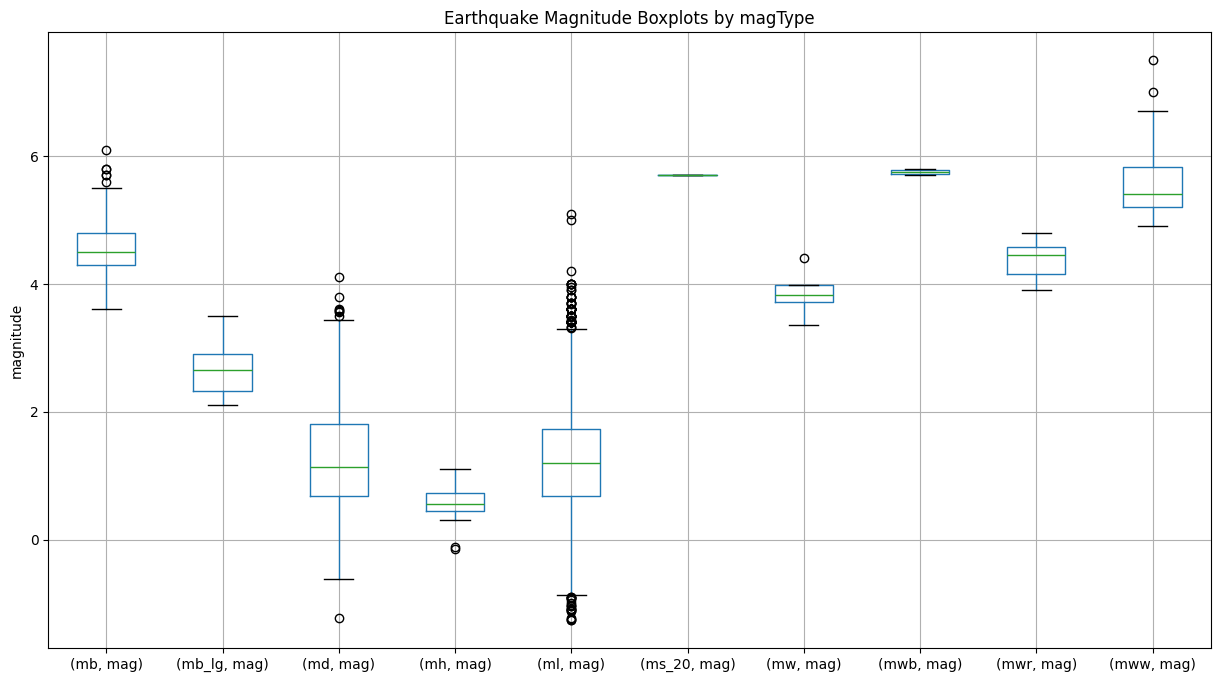

In [54]:
quakes[['mag', 'magType']].groupby('magType').boxplot(
  figsize=(15, 8), subplots=False
)
plt.title('Earthquake Magnitude Boxplots by magType')
plt.ylabel('magnitude') # label the y-axis (discussed in chapter 6)

**Counts and frequencies**

*Bar charts*

Text(0, 0.5, 'volume')

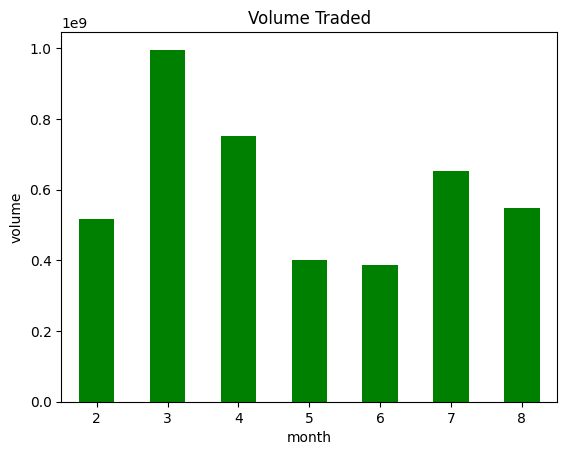

In [55]:
fb['2018-02':'2018-08'].assign(
  month=lambda x: x.index.month
).groupby('month').sum().volume.plot.bar(
  color='green', rot=0, title='Volume Traded'
)
plt.ylabel('volume') # label the y-axis (discussed in chapter 6)

Text(0.5, 0, 'earthquakes')

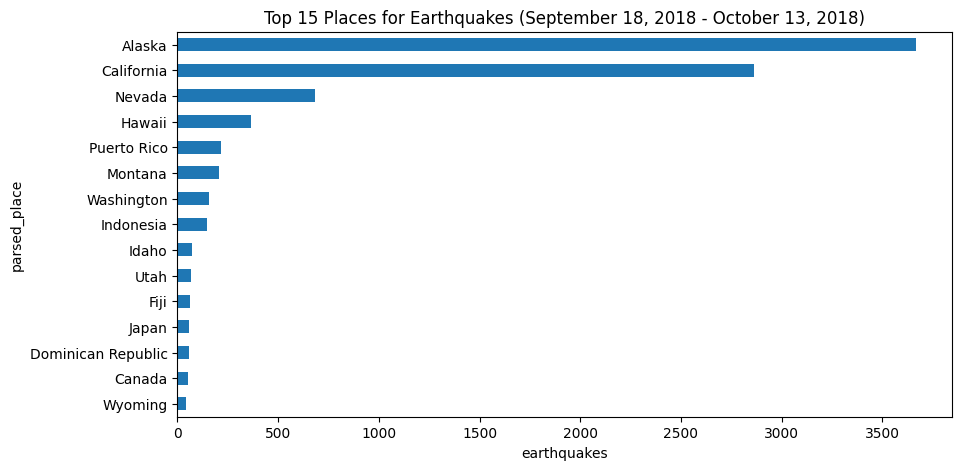

In [56]:
quakes.parsed_place.value_counts().iloc[14::-1,].plot(
  kind='barh', figsize=(10, 5),
  title='Top 15 Places for Earthquakes '\
    '(September 18, 2018 - October 13, 2018)'
)
plt.xlabel('earthquakes') # label the x-axis (discussed in chapter 6)

Text(0.5, 0, 'tsunamis')

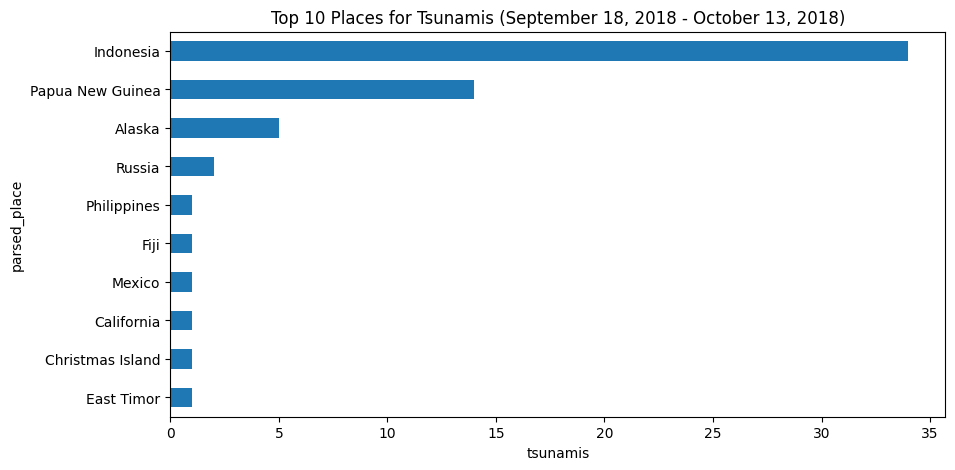

In [57]:
quakes.groupby('parsed_place').tsunami.sum().sort_values().iloc[-10::,].plot(
  kind='barh', figsize=(10, 5),
  title='Top 10 Places for Tsunamis '\
    '(September 18, 2018 - October 13, 2018)'
)
plt.xlabel('tsunamis') # label the x-axis (discussed in chapter 6)

Text(0, 0.5, 'count')

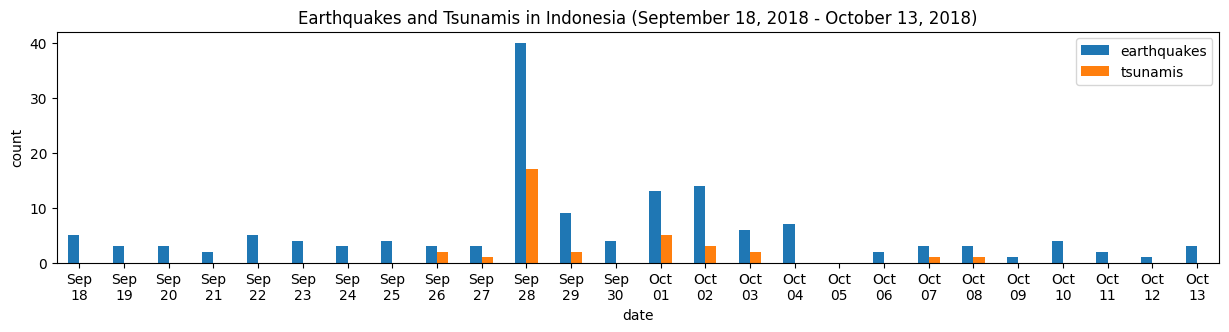

In [58]:
indonesia_quakes = quakes.query('parsed_place == "Indonesia"').assign(
  time=lambda x: pd.to_datetime(x.time, unit='ms'),
  earthquake=1
).set_index('time').resample('1D').sum()

indonesia_quakes.index = indonesia_quakes.index.strftime('%b\n%d')

indonesia_quakes.plot(
  y=['earthquake', 'tsunami'], kind='bar', figsize=(15, 3), rot=0,
  label=['earthquakes', 'tsunamis'],
  title='Earthquakes and Tsunamis in Indonesia '\
    '(September 18, 2018 - October 13, 2018)'
)
# label the axes (discussed in chapter 6)
plt.xlabel('date')
plt.ylabel('count')

* 9.3 Pandas Plotting Subpackage

#**Data Analysis:**
* Provide comments on output from the procedures above.

#**Supplementary Activity:** <br>
Using the CSV files provided and what we have learned so far in this module complete the following exercises:




*1.   Plot the rolling 20-day minimum of the Facebook closing price with the pandas plot() method*

*2.   Create a histogram and KDE of the change from open to close in the price of Facebook stock.*

*3.   Using the earthquake data, create box plots for the magnitudes of each magType used in Indonesia.*

*4.   Make a line plot of the difference between the weekly maximum high price and the weekly minimum low price for Facebook. This should be a single
line.*


*5.  Using matplotlib and pandas, create two subplots side-by-side showing the effect that after-hours trading has had on Facebook's stock price: <br>*
*  The first subplot will contain a line plot of the daily difference between that day's opening price and the prior day's closing price (be sure to review the Time series section of Aggregating Pandas DataFrames for an easy way to do this).
*  The second subplot will be a bar plot showing the net effect this had monthly, using resample().
*  Bonus #1: Color the bars according to whether they are gains in the stock price (green) or drops in the stock price (red).
*  Bonus #2: Modify the x-axis of the bar plot to show the threeletter abbreviation for the month.



#**Summary/Conclusion:** <br>
*Put here*